In [1]:
from pydicom import examples

ds = examples.mr

In [2]:
arr = ds.pixel_array
arr

array([[ 905, 1019, 1227, ...,  302,  304,  328],
       [ 628,  770,  907, ...,  298,  331,  355],
       [ 498,  566,  706, ...,  280,  285,  320],
       ...,
       [ 334,  400,  431, ..., 1094, 1068, 1083],
       [ 339,  377,  413, ..., 1318, 1346, 1336],
       [ 378,  374,  422, ..., 1369, 1129,  862]],
      shape=(64, 64), dtype=int16)

In [3]:
import matplotlib.pyplot as plt
from pydicom import dcmread
from pydicom.data import get_testdata_file

path = get_testdata_file("CT_small.dcm")
ds = dcmread(path)
ds

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 192
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.2
(0002,0013) Implementation Version Name         SH: 'DCTOOL100'
(0002,0016) Source Application Entity Title     AE: 'CLUNIE1'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '20040119'
(0008,0013) Instance Creation Time              TM: '072731'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.

In [4]:
pat_name = ds.PatientName
print(f"Patient's Name...: {pat_name.family_comma_given()}")
print(f"Patient ID.......: {ds.PatientID}")
print(f"Modality.........: {ds.Modality}")
print(f"Study Date.......: {ds.StudyDate}")
print(f"Image size.......: {ds.Rows} x {ds.Columns}")
print(f"Pixel Spacing....: {ds.PixelSpacing}")

Patient's Name...: CompressedSamples, CT1
Patient ID.......: 1CT1
Modality.........: CT
Study Date.......: 20040119
Image size.......: 128 x 128
Pixel Spacing....: [0.661468, 0.661468]


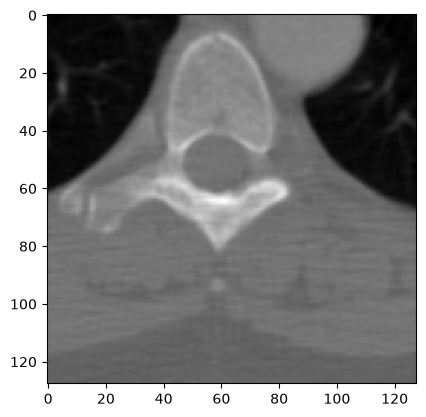

In [5]:
plt.imshow(ds.pixel_array, cmap=plt.cm.gray)

In [6]:
ct_hu = ds.pixel_array
min, max = arr.min(), arr.max()
print("readed hu range:", min, max)

readed hu range: 127 2145


In [7]:
ct_hu = ct_hu * ds.RescaleSlope + ds.RescaleIntercept
print("Raw HU range:", ct_hu.min(), ct_hu.max())

Raw HU range: -896.0 1167.0


In [8]:
import numpy as np
def apply_window(img_hu, level, width):
    low = (level - width) / 2
    high = (level + width) / 2
    windowed = np.clip(img_hu, low, high)
    windowed = (windowed - low) / (high - low)
    return windowed.astype(np.float32)



In [9]:
soft_tissue_window = apply_window(ct_hu, level=40, width=400)
bone_window = apply_window(ct_hu, level=400, width=1800)

In [10]:
body_voxels = ct_hu [ct_hu > -500]
mean, std = body_voxels.mean(), body_voxels.std()
zscore = (ct_hu - mean) / std
print(f"Body-region mean={mean:.1f} HU, std={std:.1f} HU")


Body-region mean=61.3 HU, std=175.4 HU


# Working with actual data

In [11]:
import nibabel as nib
import numpy as np

In [12]:
# --- Load the real MRI volume and its matching label mask ---
img = nib.load("anatomical.nii").get_fdata()
lbl = nib.load("anatomical_label.nii.gz").get_fdata()

print("Image (the scan) shape:", img.shape)   # (width, height, depth) = number of 2D slices stacked
print("Label (the mask) shape:", lbl.shape)   # same shape -- one mask value per image voxel


Image (the scan) shape: (33, 41, 25)
Label (the mask) shape: (33, 41, 25)


In [13]:
#  --- The mask only has two values: is this voxel the target region or not ---
print("\nUnique values in the label:", np.unique(lbl))
print("This confirms it's a BINARY mask: 0 = background, 1 = target region")

# --- Find WHICH 2D slice actually has something labeled ---
# lbl.shape[2] is the number of slices along the 3rd axis
for z in range(lbl.shape[2]):
    n_labeled_pixels = lbl[:, :, z].sum()

    if n_labeled_pixels > 0:
        print(f"\nSlice z={z} has {int(n_labeled_pixels)} labeled pixels out of "
              f"{lbl.shape[0]*lbl.shape[1]} total pixels in that slice "
              f"({100*n_labeled_pixels/(lbl.shape[0]*lbl.shape[1]):.2f}%)")



Unique values in the label: [0. 1.]
This confirms it's a BINARY mask: 0 = background, 1 = target region

Slice z=12 has 330 labeled pixels out of 1353 total pixels in that slice (24.39%)


In [14]:
z=12 
img_2d = img[:, :, z]
mask_2d = lbl[:, :, z]

print("Image shape:", img_2d.shape)
print("2D image value range:", img_2d.min(), "to", img_2d.max())
print("Label shape:", mask_2d.shape)
print("2D mask value range:", mask_2d.min(), "to", mask_2d.max())

Image shape: (33, 41)
2D image value range: -136.0 to 13705.0
Label shape: (33, 41)
2D mask value range: 0.0 to 1.0


Text(0.5, 1.0, 'With label overlay (red)')

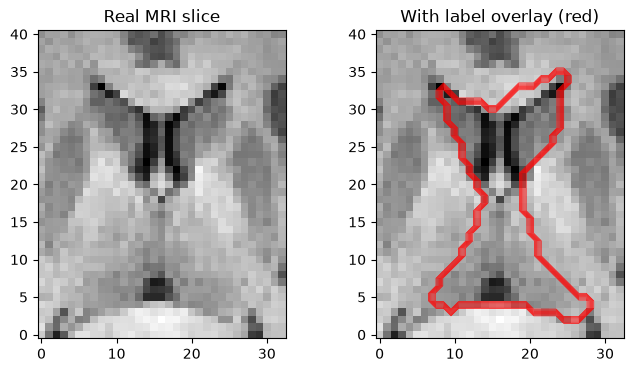

In [15]:
# --- Look at it ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_2d.T, cmap="gray", origin="lower")
axes[0].set_title("Real MRI slice")
axes[1].imshow(img_2d.T, cmap="gray", origin="lower")
axes[1].contour(mask_2d.T, colors="red", linewidths=.5, origin="lower")
axes[1].set_title("With label overlay (red)")
# for ax in axes:
#     ax.axis("off")

In [16]:
image_norm = (img_2d - img_2d.mean()) / img_2d.std()
print("Before normalizing: min", img_2d.min(), "max", img_2d.max())
print("After normalizing:  min", round(image_norm.min(), 2), "max", round(image_norm.max(), 2))

Before normalizing: min -136.0 max 13705.0
After normalizing:  min -3.72 max 2.21


In [17]:
import torch
image_tensor = torch.from_numpy(image_norm).float().unsqueeze(0).unsqueeze(0)
mask_tensor = torch.from_numpy(mask_2d).float().unsqueeze(0).unsqueeze(0)

print("\nimage_tensor shape:", image_tensor.shape, " <- (batch=1, channels=1, height, width)")
print("mask_tensor shape:", mask_tensor.shape)


image_tensor shape: torch.Size([1, 1, 33, 41])  <- (batch=1, channels=1, height, width)
mask_tensor shape: torch.Size([1, 1, 33, 41])


In [18]:
import torch.nn as nn
class TinySegModel(nn.Module):
    def __init__(self, kernel_size = 3, padding = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=kernel_size,padding= padding)
        self.conv2 = nn.Conv2d(8, 8, kernel_size=kernel_size, padding=padding)
        self.conv3 = nn.Conv2d(8, 1, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)

        x = self.conv3(x)

        return x

In [19]:
model = TinySegModel()

In [20]:
with torch.no_grad():
    output = model(image_tensor)

output.shape

torch.Size([1, 1, 33, 41])

In [21]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 30


In [22]:
model.train()
for step in range(epochs):
    optimizer.zero_grad()                        # clear old gradients
    output = model(image_tensor)                  # forward pass: get predictions
    loss = loss_fn(output, mask_tensor)            # compare predictions to truth
    loss.backward()                                # compute gradients (how to adjust weights)
    optimizer.step()                               # actually adjust the weights

    if step % 5 == 0 or step == 29:
        print(f"step {step:2d}   loss = {loss.item():.4f}")

step  0   loss = 0.7263
step  5   loss = 0.5555
step 10   loss = 0.4687
step 15   loss = 0.4796
step 20   loss = 0.4441
step 25   loss = 0.4349
step 29   loss = 0.4270


In [23]:
with torch.no_grad():
    model.eval()
    raw_output = model(image_tensor)          # raw scores
    probs = torch.sigmoid(raw_output)          # turn into 0-1 probabilities
    predicted_mask = (probs > 0.5).float()     # threshold at 0.5 -> final yes/no mask

probs_2d = probs[0, 0].numpy()
pred_2d = predicted_mask[0, 0].numpy()

print("Predicted probability range:", probs_2d.min(), "to", probs_2d.max())
print("Predicted mask: how many pixels marked as target?", int(pred_2d.sum()),
      " (true answer:", int(mask_2d.sum()), ")")

Predicted probability range: 0.0034465573 to 0.96460795
Predicted mask: how many pixels marked as target? 237  (true answer: 330 )


# U NET

In [ ]:
import torch.nn as nn
class DoubleConv(nn.Module):
    def init(self, in_ch, out_ch, k=3, p=1):
        super.__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch,kernel_size=k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=out_ch, out_channels=out_ch,kernel_size=k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [3]:
class UNet(nn.Module):
    def __init__(self,  in_ch=1, out_ch=1, base = 16):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base *2)
        self.enc3 = DoubleConv(base*2, base *4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base)

        self.out_conv = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1()
        e2 = self.enc2(self.pool(x))
        e3 = self.enc3(self.pool(x))
        b = self.bottleneck(self.pool(x))

        d3 = self.up3(b)
        d3 = self.dec3(torch.concat([d3, e3], dim=1)) #skip connection
        d2 = self.up2(d3)
        d2 = self.dec2(torch.concat([d2, e2], dim=1)) #skip connection
        d1 = self.up1(d2)
        d1 = self.dec1(torch.concat([d1, e1], dim=1)) #skip connection

        return self.out_conv(d1)


In [4]:
def dice_loss(logits, target, eps = 1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1 )
    target = target.view(target.size(0), -1)

    intersection = (probs * target).sum(dim=1)
    union = probs.sum(dim=1) + target.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return dice
